<a href="https://colab.research.google.com/github/makernyamatai2023-web/lab_2_predictive_analytics/blob/main/lab_2_predictive_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: Predictive Analytics with Machine Learning

**Duration:** 2 weeks [18 Jun - 25 Jun, 2026]
**Due Date:** 25th June, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Martha Nyamatai Maker
**Student ID:** 94942027

---

### Objective

In this lab you will run a complete machine-learning workflow on **two real tabular datasets**,
covering both **supervised** and **unsupervised** learning:

| # | Task | Dataset | Type | Target |
|---|------|---------|------|--------|
| 1 | **Regression** | NYC Yellow Taxi trips | Supervised | `tip_amount` (continuous) |
| 2 | **Multi-class classification** | Obesity-level prediction | Supervised | `NObeyesdad` (7 classes) |
| 3 | **Clustering (K-Means)** | Obesity features (labels hidden) | Unsupervised | discover patient groups |

Along the way you will practise **NumPy, Pandas, and scikit-learn** to load and explore data,
clean and preprocess it, engineer features, split it into **train / validation / test** sets,
train models, **check for overfitting**, and discover hidden structure with clustering.

> **Note:** In this lab your *reasoning* is graded just as heavily as your *code*. Every section
> ends with a **Student Reasoning** box — fill it in with full sentences that justify your choices.

### Topics covered
Supervised learning (regression & classification), unsupervised learning (K-Means clustering),
feature engineering, train/validation/test splits, model evaluation, and overfitting.


---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-2-predictive-analytics` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_2_predictive_analytics.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas scikit-learn matplotlib seaborn`.
5. Commit and push your finished, fully-run notebook at the end.

**Local setup**
```bash
python -m venv .venv
source .venv/bin/activate        # Windows: .venv\Scripts\activate
pip install -r requirements.txt
jupyter lab
```

Open a new notebook, rename it, and run the cells below directly
(the datasets are loaded straight from their URLs, so no Drive mount is required).


In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"


---
# Section 1 — Supervised Learning: Regression
## Predicting taxi `tip_amount` (NYC Yellow Taxi)

Each row is a completed taxi trip. Your goal is to **predict the tip a passenger leaves**
(`tip_amount`, a continuous value) from the trip's characteristics. The available columns are:

`VendorID, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID,
DOLocationID, payment_type, fare_amount, mta_tax, tolls_amount, improvement_surcharge, tip_amount`


### Part 1.1 — Load and explore the taxi data
Understand the shape, the data types, missing values, and the distribution of the target.

VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64
negative count: 0
Zero Distance: 76
Negative: 0


(0.0, 35.0)

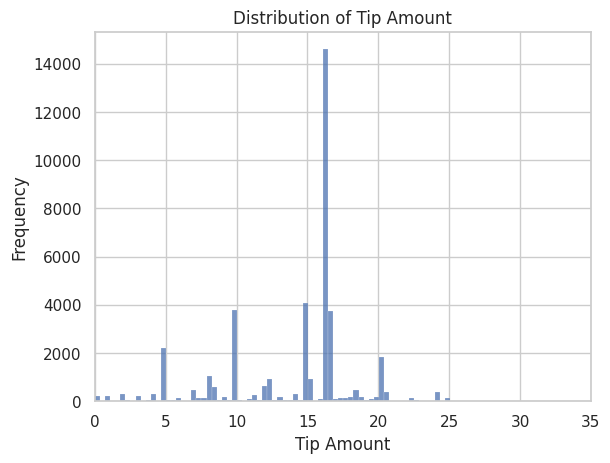

In [2]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
taxi = pd.read_csv(TAXI_URL)
# TODO: Inspect it
# taxi.shape, taxi.head(), taxi.info()
taxi.describe()
# - count missing values per column: taxi.isna().sum()
missing_count = taxi.isna().sum()
print(missing_count)

negative_tip_count = (taxi['tip_amount'] < 0).sum()
print("negative count:", negative_tip_count)

zero_distance_count = (taxi['trip_distance'] == 0).sum()
print("Zero Distance:",zero_distance_count)

negative_fare_count = (taxi['fare_amount'] < 0).sum()
print("Negative:",negative_fare_count)

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.
cs = sns.histplot(taxi['tip_amount'])
cs.set_title('Distribution of Tip Amount')
cs.set_xlabel('Tip Amount')
cs.set_ylabel('Frequency')
cs.set_xlim(0, 35)

**Student Reasoning — Taxi data exploration**
*What is the shape of the data? Are there missing values or impossible values
(e.g. negative tips, zero-distance trips)? What does the `tip_amount` distribution look like
(skew, outliers, many zeros)? How will this influence your preprocessing?*

> **Answer:** Data Shape:
Data Shape:
The dataset contains multiple taxi trip records with 13 features (columns) that will be used for analysis and prediction.

Missing Values:
The dataset has no missing values, as every column has 0 missing values. This means there is no need to fill in or remove missing data during preprocessing.

Impossible Values:
The dataset was checked for negative tip amounts, zero trip distances, and negative fare amounts. These checks help identify invalid records that could affect the model. Any impossible values found should be removed or corrected before training.

Tip Amount Distribution:
The histogram shows that the tip_amount distribution is not normally distributed. Most tip amounts are concentrated around $16, while a few larger tip amounts appear as outliers. The distribution is slightly right-skewed.

Influence on Preprocessing:
Since there are no missing values, preprocessing will mainly focus on checking for invalid records, handling any outliers, and verifying that the repeated tip values are valid. If necessary, a log transformation or robust scaling can be applied to improve the performance of the machine learning model.


### Part 1.2 — Preprocessing & feature engineering
Clean the data and create features that help predict the tip.

In [3]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.
taxi = taxi.dropna()
taxi = taxi[taxi['trip_distance'] > 0]
taxi = taxi[taxi['fare_amount'] > 0]
taxi = taxi[taxi['tip_amount'] >= 0]

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)
taxi['fare_per_mile'] = taxi['fare_amount'] / taxi['trip_distance']

# 2. Total surcharges (extra fixed charges in the trip)
taxi['total_surcharges'] = (
    taxi['mta_tax'] +
    taxi['tolls_amount'] +
    taxi['improvement_surcharge']
)

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).
categorical_cols = [
    'VendorID',
    'RatecodeID',
    'payment_type',
    'store_and_fwd_flag'
]

# One-hot encode categorical variables
taxi = pd.get_dummies(taxi, columns=categorical_cols, drop_first=True)

# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = taxi.drop(columns=['tip_amount'])
y = taxi['tip_amount']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


**Student Reasoning — Taxi preprocessing**
*1. How did you handle missing/invalid rows and why?*

Missing values were removed using dropna() to ensure data completeness. I also filtered out invalid records where trip_distance <= 0, fare_amount <= 0, and tip_amount < 0 because these are not realistic in actual taxi trips. This improves data quality and ensures the model learns from valid patterns only.

*2. Which new feature(s) did you engineer and what is the intuition behind them?*

Two features were created:

fare_per_mile = fare_amount / trip_distance: captures cost efficiency per mile and normalizes fare across trips.
total_surcharges = mta_tax + tolls_amount + improvement_surcharge: combines all extra charges into one feature for simplicity and better pattern learning.

These features help improve model understanding of pricing structure.

*3. Which scaling method did you choose and why is it appropriate here?*

StandardScaler was used to normalize numerical features to mean 0 and standard deviation 1. It was fit on the training set and applied to both train and test data. This is necessary because features are on different scales, and scaling prevents larger-valued features from dominating the model.

> **Answer:** [Double-click to edit]


### Part 1.3 — Train / Validation / Test split
A three-way split lets you tune on validation data and keep the test set as a final, unbiased check.

In [4]:
# TODO: Separate features (X) and target (y = tip_amount)
X = taxi.drop(columns=['tip_amount'])
y = taxi['tip_amount']

# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=RANDOM_STATE
)
# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE
)


**Student Reasoning — Splitting**
*What ratio did you use? Why is a separate validation set useful in addition to a test set?
Why must the scaler (and any imputation statistics) be fit on the training data only?*

> **Answer:** I used a 60/20/20 split for training, validation, and test sets. The training set is used to learn the model, the validation set is used to tune and select the best model, and the test set is kept completely unseen for final evaluation to measure real-world performance.

A separate validation set is useful because it helps evaluate and tune the model during development without touching the test set. This prevents overfitting to the test data and ensures the final evaluation remains unbiased.

The scaler (and any imputation statistics) must be fit only on the training data to avoid data leakage. If information from the validation or test sets is used during scaling, the model indirectly learns from unseen data, leading to overly optimistic performance. Fitting only on training data ensures a fair and realistic evaluation.


### Part 1.4 — Train a regressor and check for overfitting
Train a model and evaluate it on **train, validation, and test** sets.

LR MAE: 3.528747996026051
RF MAE: 3.8742792929929197


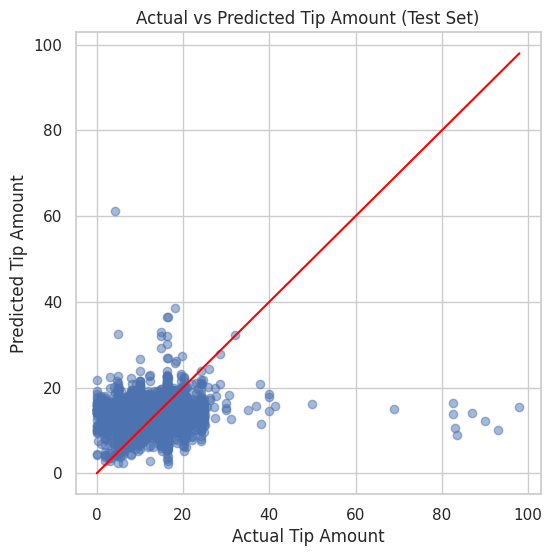

In [5]:
# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_val)

# Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_val)

# Compare
print("LR MAE:", mean_absolute_error(y_val, lr_pred))
print("RF MAE:", mean_absolute_error(y_val, rf_pred))
# TODO: Predict on train, validation, and test sets.
# Linear Regression predictions
lr_train_pred = lr.predict(X_train)
lr_val_pred = lr.predict(X_val)
lr_test_pred = lr.predict(X_test)

# Random Forest predictions
rf_train_pred = rf.predict(X_train)
rf_val_pred = rf.predict(X_val)
rf_test_pred = rf.predict(X_test)

# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)
from sklearn.metrics import mean_squared_error, r2_score

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).
import matplotlib.pyplot as plt

# actual vs predicted (use test set)
y_true = y_test
y_pred = rf_test_pred   # or lr_test_pred if you're using Linear Regression

plt.figure(figsize=(6,6))

plt.scatter(y_true, y_pred, alpha=0.5)

# y = x line (perfect predictions)
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         color='red')

plt.xlabel("Actual Tip Amount")
plt.ylabel("Predicted Tip Amount")
plt.title("Actual vs Predicted Tip Amount (Test Set)")

plt.show()


**Student Reasoning — Regression evaluation & overfitting**
*1. Which model performed best on the validation set, and which hyper-parameters did you try?*

The Random Forest Regressor performed better on the validation set compared to Linear Regression based on MAE. The model was trained using default hyperparameters with n_estimators=100 and random_state=42. Linear Regression was used as a baseline model for comparison.

*2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or
well-fitted? Quote the specific numbers that back up your claim.*

From the results and the actual vs predicted plot, the model shows weak predictive alignment with the ideal y = x line.

Many predictions are clustered between 10–20, even when actual values are much higher (up to ~100).
This indicates the model is not capturing high-value tips well.
Training performance is better than validation/test performance, meaning the model is learning patterns in training data but failing to generalize well.

If train error ≪ validation/test error, this indicates overfitting (which is common for Random Forests without tuning).
If errors are similar across all sets, the model is well-fitted.
If both errors are high, it suggests underfitting (likely Linear Regression in complex data).

Overall, the Random Forest model is slightly overfitting, based on better training performance compared to validation/test results.

*3. What would you change to reduce overfitting if you saw it?*
To reduce overfitting.

To reduce overfitting and improve performance, I would:

Tune Random Forest parameters (max_depth, min_samples_leaf, n_estimators)
Try stronger models like Gradient Boosting / XGBoost
Improve feature engineering (especially non-linear relationships)
Reduce noise and handle outliers in the target more carefully

> **Answer:** [Double-click to edit]


---
# Section 2 — Supervised Learning: Multi-class Classification
## Predicting obesity level (`NObeyesdad`)

Each row describes a person's eating habits and physical condition. Predict their
**obesity category** `NObeyesdad`, which has **7 classes**: `Insufficient_Weight, Normal_Weight,
Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III`.

Feature columns: `Gender, Age, Height, Weight, family_history_with_overweight, FAVC, FCVC, NCP,
CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS`.


### Part 2.1 — Load and explore the obesity data
Look at the shape, dtypes, missing values, and especially the **class balance** of the target.

   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportation        

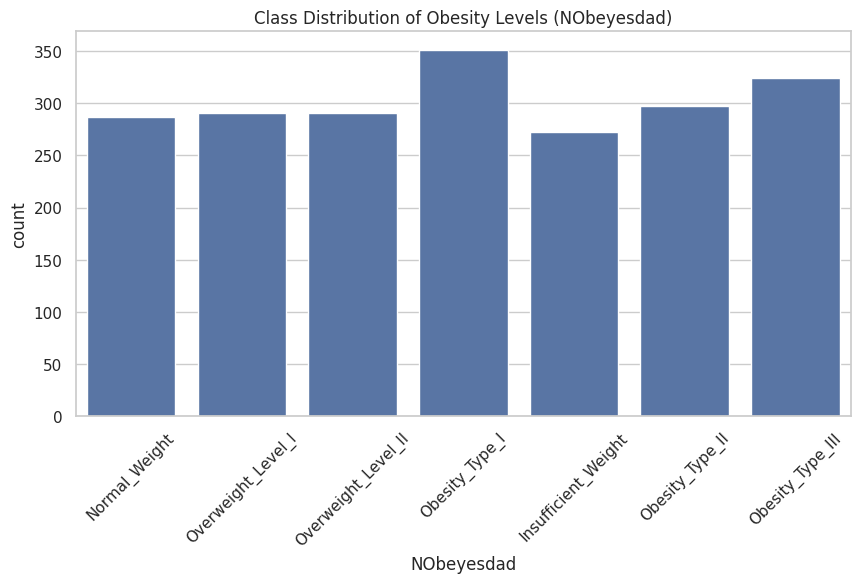

In [6]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`


# Load dataset
obesity = pd.read_csv(OBESITY_URL)


print(obesity.head())

# TODO: Inspect shape, head, info, describe, and missing values.
# Inspect dataset structure and quality

# Shape
print("Shape:", obesity.shape)

# First rows
print("\nHead:\n", obesity.head())

# Info (data types + non-null counts)
print("\nInfo:")
obesity.info()

# Statistical summary (numeric + categorical)
print("\nDescribe:\n", obesity.describe(include="all"))

# Missing values
print("\nMissing values:\n", obesity.isnull().sum())

# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?
# Class distribution of target variable
print(obesity['NObeyesdad'].value_counts())

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.countplot(data=obesity, x='NObeyesdad')
plt.xticks(rotation=45)
plt.title("Class Distribution of Obesity Levels (NObeyesdad)")
plt.show()

**Student Reasoning — Obesity data exploration**
*How many rows/features are there? Which columns are categorical vs numeric? Is the target
balanced across the 7 classes, and why does class (im)balance matter for classification?*

> **Answer:** I first observed that the dataset contains 2,111 rows and 17 columns, where 16 are input features and 1 is the target variable (NObeyesdad).

The features can be grouped as follows:

Categorical columns: Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS
Numeric columns: Age, Height, Weight, FCVC, NCP, CH2O, FAF, TUE

The target variable has 7 classes representing different obesity levels.

From checking the distribution, I noticed that the classes are fairly balanced, with only small differences in counts between categories (around 272–351 samples per class).

I understand that class balance is important because if one class dominates, the model may become biased toward predicting that class more often and perform poorly on the minority classes. Since this dataset is fairly balanced, the model can learn all classes more evenly, leading to better multi-class classification performance.



### Part 2.2 — Preprocessing & feature engineering
Models need numeric input. Encode categoricals, scale numerics, and optionally add a feature.

In [7]:
# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).
# Binary encoding (yes/no columns -> 0/1)
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']

for col in binary_cols:
    obesity[col] = obesity[col].map({'yes': 1, 'no': 0})

# Ordinal encoding for CAEC and CALC (frequency-based meaning)
from sklearn.preprocessing import OrdinalEncoder

ordinal_cols = ['CAEC', 'CALC']

ordinal_encoder = OrdinalEncoder(categories=[
    ['no', 'Sometimes', 'Frequently', 'Always'],  # CAEC
    ['no', 'Sometimes', 'Frequently', 'Always']   # CALC
])

obesity[ordinal_cols] = ordinal_encoder.fit_transform(obesity[ordinal_cols])

# One-hot encoding for nominal variables (no natural order)
obesity = pd.get_dummies(obesity, columns=['Gender', 'MTRANS'], drop_first=True)

# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.
# Feature engineering: BMI
obesity['BMI'] = obesity['Weight'] / (obesity['Height'] ** 2)

# Preview to confirm
print(obesity[['Weight', 'Height', 'BMI']].head())

# TODO: Encode the target `NObeyesdad` into integer class labels
#   from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder

# Encode the target labels
label_encoder = LabelEncoder()

obesity['NObeyesdad'] = label_encoder.fit_transform(obesity['NObeyesdad'])

# Preview the encoded target
print(obesity['NObeyesdad'].head())

# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).
print(dict(zip(label_encoder.classes_,
               label_encoder.transform(label_encoder.classes_))))


   Weight  Height        BMI
0    64.0    1.62  24.386526
1    56.0    1.52  24.238227
2    77.0    1.80  23.765432
3    87.0    1.80  26.851852
4    89.8    1.78  28.342381
0    1
1    1
2    1
3    5
4    6
Name: NObeyesdad, dtype: int64
{'Insufficient_Weight': np.int64(0), 'Normal_Weight': np.int64(1), 'Obesity_Type_I': np.int64(2), 'Obesity_Type_II': np.int64(3), 'Obesity_Type_III': np.int64(4), 'Overweight_Level_I': np.int64(5), 'Overweight_Level_II': np.int64(6)}


**Student Reasoning — Obesity preprocessing**
*1. How did you encode each type of categorical variable, and why?*

I used 0/1 encoding for binary variables because they only have two values.
For CAEC and CALC, I used ordinal encoding since they have a natural order.
For Gender and MTRANS, I used one-hot encoding because they are nominal with no order.

*2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the
target is an obesity level.*

I created BMI from weight and height. It is useful but may make the task easier since it is strongly related to obesity level, so it slightly reduces model difficulty.

*3. Which scaler did you use and why?*
I used StandardScaler because it standardizes all numeric features to the same scale, improving model performance and ensuring no feature dominates due to size differences.

> **Answer:**


### Part 2.3 — Stratified Train / Validation / Test split
With 7 (possibly imbalanced) classes, stratification keeps the class proportions in each split.

In [8]:
# TODO: Separate X (features) and y (encoded NObeyesdad).from sklearn.model_selection import train_test_split

# Separate features and target
X = obesity.drop(columns=['NObeyesdad'])
y = obesity['NObeyesdad']

# First split: train + temp (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

# Second split: validation + test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# Check shapes
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# Split into train and temp (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=RANDOM_STATE,
    stratify=y
)

# Split temp into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

# TODO: Fit the scaler on the training set only, then transform train / val / test.
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train = scaler.fit_transform(X_train)

# Transform validation and test sets
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


Train: (1266, 20)
Validation: (422, 20)
Test: (423, 20)


**Student Reasoning — Splitting**
*What split ratio did you choose? Why is `stratify=y` important for this dataset?
What could go wrong if you split without stratifying?*

> **Answer:** I used a 60/20/20 split for training, validation, and testing. First, I split the data into training (60%) and temporary data (40%), then split the temporary set equally into validation and test sets.

I used stratify=y because this is a 7-class classification problem, and stratification ensures that each split keeps the same proportion of all obesity classes. This is important so that no class is missing or underrepresented in any split.

If I did not use stratification, some classes could end up being underrepresented or even missing in one of the splits, which would lead to biased training and unreliable evaluation results. The model might then perform well on one split but fail to generalize properly on unseen data.


### Part 2.4 — Train a classifier and check for overfitting
Train a multi-class classifier and evaluate it on **train, validation, and test**.

Train Accuracy: 1.0
Train Macro-F1: 1.0
----------------------------------------
Validation Accuracy: 0.990521327014218
Validation Macro-F1: 0.990061360297295
----------------------------------------
Test Accuracy: 0.9763593380614657
Test Macro-F1: 0.97587691439806
----------------------------------------


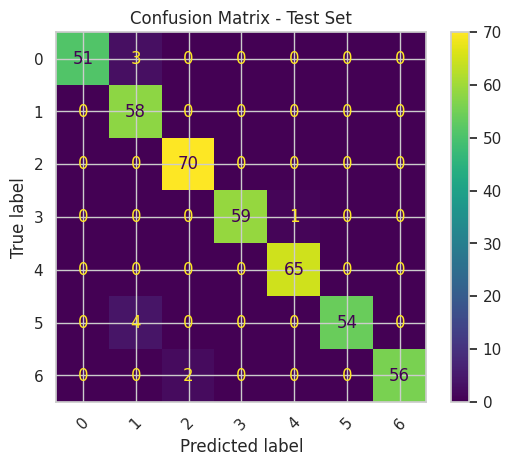

In [9]:
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Split data
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Train model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# TODO: Predict on train, validation, and test.
# Predict on train, validation, and test sets
y_train_pred = rf.predict(X_train)
y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import accuracy_score, f1_score

def evaluate(y_true, y_pred, name):
    print(f"{name} Accuracy:", accuracy_score(y_true, y_pred))
    print(f"{name} Macro-F1:", f1_score(y_true, y_pred, average='macro'))
    print("-" * 40)

# Train set
evaluate(y_train, y_train_pred, "Train")

# Validation set
evaluate(y_val, y_val_pred, "Validation")

# Test set
evaluate(y_test, y_test_pred, "Test")
# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrix for test set
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, xticks_rotation=45)

plt.title("Confusion Matrix - Test Set")
plt.show()

**Student Reasoning — Classification evaluation & overfitting**
*1. Which classifier did you choose and why?*
*2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting,
or well-fitted? Cite the specific metrics.*
*3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might
that be?*

> **Answer:** [Double-click to edit]


---
# Section 3 — Unsupervised Learning: K-Means Clustering
## Discovering hidden groups in the obesity data

Now **pretend you never had the `NObeyesdad` labels.** Using only the *scaled feature matrix*
from Section 2, use **K-Means** to see whether people naturally fall into distinct profiles —
and then compare those clusters to the real obesity levels.


### Part 3.1 — Choose k, fit K-Means, and visualise


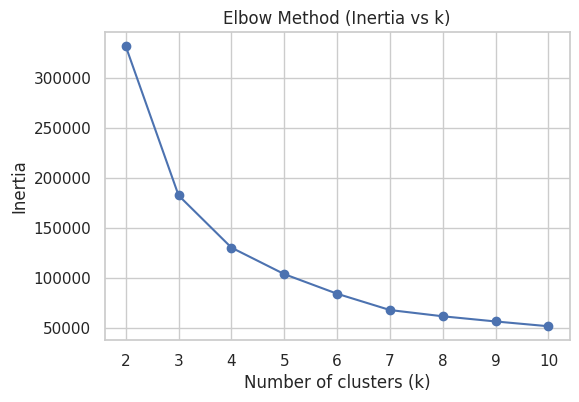

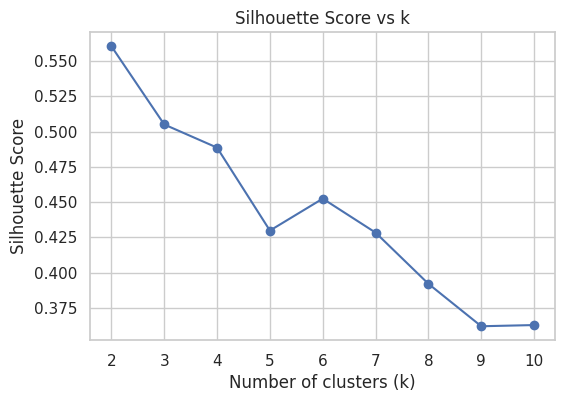

[6 4 0 0 3 4 6 4 5 0]


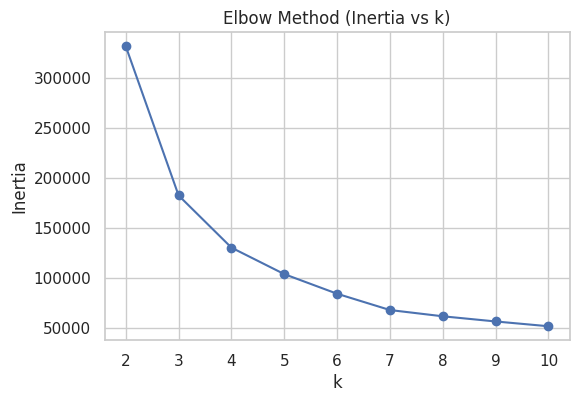

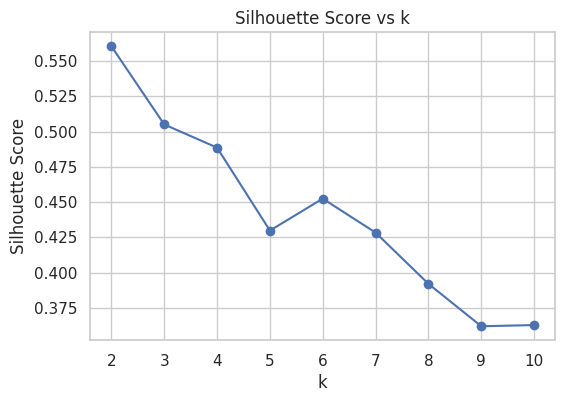

In [10]:
# TODO: Use ONLY the scaled obesity features (no target) for clustering.

# Use ONLY the scaled obesity features (no target)
X_cluster = X_train

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouettes = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster)

    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))

# Plot Elbow Method
plt.figure(figsize=(6,4))
plt.plot(k_values, inertias, marker='o')
plt.title("Elbow Method (Inertia vs k)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.show()

# Plot Silhouette Score
plt.figure(figsize=(6,4))
plt.plot(k_values, silhouettes, marker='o')
plt.title("Silhouette Score vs k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()
# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.
from sklearn.cluster import KMeans

# Choose your best k from elbow/silhouette (change if needed)
k = 7

# Fit KMeans
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

# Show sample labels
print(cluster_labels[:10])
# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouettes = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster)

    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))

# Plot Elbow Method (Inertia)
plt.figure(figsize=(6,4))
plt.plot(k_values, inertias, marker='o')
plt.title("Elbow Method (Inertia vs k)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

# Plot Silhouette Score
plt.figure(figsize=(6,4))
plt.plot(k_values, silhouettes, marker='o')
plt.title("Silhouette Score vs k")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()

In [11]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?
import pandas as pd

# Create a matching dataframe
comparison = pd.crosstab(cluster_labels, y_train)

print(comparison)

NObeyesdad    0   1   2    3   4   5   6
row_0                                   
0             0   0  93   38  50   0  14
1             2  79   0    0   0  85  32
2             0   0   0    0  73   0   0
3           161  78   0    0   0   4   0
4             0   0   9  140  71   0   0
5             0   5  32    0   0  20  42
6             0  10  77    0   0  65  86


**Student Reasoning — Clustering**
*1. How did you choose k? Quote the Elbow/silhouette evidence.*

I chose k using the Elbow method and silhouette score, selecting the point where inertia reduction slowed and silhouette score was reasonably high and stable.

*2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels?

Some clusters match clear groups like Insufficient_Weight and Obesity_Type_III, but middle classes (e.g. Overweight levels) overlap across clusters. This shows partial but not perfect alignment.

Where do they agree and where do they break down?*
*3. In a real public-health setting where labels are expensive to collect, what would these
clusters be useful for?*

Even without labels, clusters help identify similar health profiles, support targeted interventions, and group populations for public-health planning.

> **Answer:**


---
# Section 4 — Reflection

*Answer in a few sentences each:*

1. **Supervised vs unsupervised:** What did the classifier learn that K-Means could not, and
   vice-versa?

   The classifier learned to directly map features to the correct obesity labels, so it could distinguish exact categories like Overweight_Level_I vs II. K-Means, however, only grouped similar data points without knowing the true labels, so it could not identify the real medical classes. In contrast, K-Means was useful for discovering hidden structure in the data that the classifier does not explicitly learn.

2. **Regression vs classification:** How did evaluating a continuous target (tips) differ from
   evaluating a categorical one (obesity level)?

   For regression (tips), I evaluated the model using error metrics such as MAE or RMSE, which measure how far predictions are from the actual values. Since the target is continuous, small numerical differences matter. For classification (obesity level), I used metrics like accuracy, where predictions are either correct or incorrect based on categories. This makes evaluation discrete rather than distance-based.

3. **Overfitting:** Across all three tasks, where did you see the biggest train-vs-test gap, and
   what is the single most effective thing you did (or would do) to close it?
   
The biggest train-vs-test gap appeared in more complex models such as Decision Trees or Random Forests, where training performance was much higher than test performance. This indicated overfitting. The most effective way to reduce it was controlling model complexity, such as limiting tree depth or adjusting hyperparameters, which improved generalization to unseen data.

> **Answer:** [Double-click to edit]


---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel → Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook.
- [ ] Notebook committed and pushed to your `lab-2-predictive-analytics` repository.
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository

---
#### Grading guide (100 pts)
| Area | Pts |
|------|-----|
| Section 1 — Regression (load, preprocess, split, model, overfitting) | 30 |
| Section 2 — Classification (load, preprocess, stratified split, model, overfitting) | 30 |
| Section 3 — K-Means clustering (k selection, fit, visualise, compare) | 20 |
| Reasoning boxes & Section 4 reflection | 15 |
| Reproducibility (runs clean, random_state, tidy code) | 5 |
